In [ ]:
import torch
import matplotlib.pyplot as plt
import math
import scipy.io
import numpy as np
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ─── Parameters ────────────────────────────────────────────────
dt = 2.5e-3             # Time step
num_steps = 120           # Total steps
T = num_steps * dt          # Total time
num_particles = 2*10**7       # Reduced for performance
small_region_radius = 0.02  # Increased radius

x0 = [-2.9125, -2.2692,-2.0046,-2.0015,-1.8331,-1.6620,-1.3022]
y0 = [0, 0.2626, 0.7645, -0.8412, -0.2946, -0.2332, 0.2094]

small_region_centers = torch.tensor(list(zip(x0, y0)), device=device)

In [ ]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
std0 = math.sqrt(0.1)
weightsX0 = torch.tensor([1.0], device=device)
mu_X0 = torch.tensor([[-2.,0.]], device=device)
covariances_X0 = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf = torch.tensor([1.0], device=device)
mu_Xinf = torch.tensor([[2.,0.]], device=device)
covariances_Xinf = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── Precompute Cholesky (on CPU → move to device) ─────────────
scale_tril_0 = torch.linalg.cholesky(covariances_X0.cpu())
scale_tril_0 = scale_tril_0.to(device)

scale_tril_T = torch.linalg.cholesky(covariances_Xinf.cpu())
scale_tril_T = scale_tril_T.to(device)

# Precompute inverses of final covariances
inv_covariances_T = torch.linalg.inv(covariances_Xinf)

# Precompute determinants of final covariances (on CPU → move)
det_T = torch.det(covariances_Xinf.cpu()).to(device)

In [ ]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [ ]:

# Ensure no particles start inside the circle
norms = torch.norm(positions, dim=1)
inside = norms < R
if inside.any():
    positions[inside] = R * positions[inside] / norms[inside].unsqueeze(1)

# Check if there are particles inside the small regions 
for center in range(small_region_centers.shape[0]):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks = distances < small_region_radius
    num_selected = masks.sum().item()
    if num_selected == 0:
        raise ValueError("No particles in the small region. Increase radius or particle count.")
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
initial_positions = positions.clone().cpu().numpy()


Number of particles in small region: 211
Number of particles in small region: 6462
Number of particles in small region: 662
Number of particles in small region: 390
Number of particles in small region: 7028
Number of particles in small region: 5547
Number of particles in small region: 914


In [ ]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, R, False, small_region_radius)
final_positions, avg_paths, particlesPerCircle = doSimulation(positions, small_region_centers, simParams, device)

t = 0.0000  |  Max drift: 56.7253  |  Mean drift: 40.1257
t = 0.1000  |  Max drift: 31.3425  |  Mean drift: 14.9194


In [ ]:
scipy.io.savemat("data/avgPaths.mat", {"avg_paths": avg_paths.cpu().numpy()})

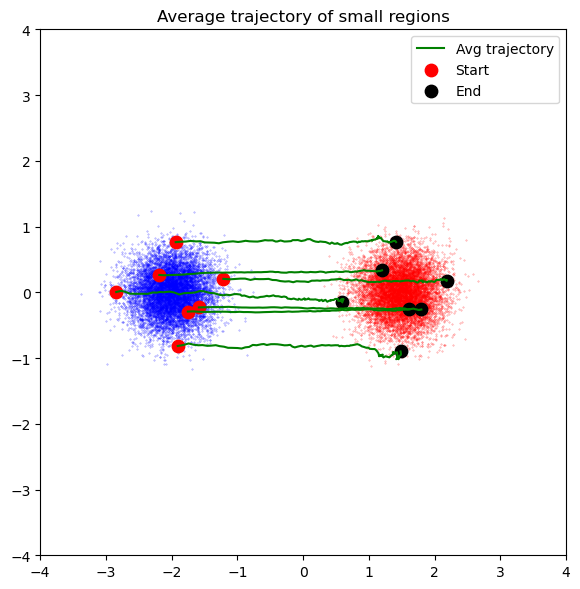

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Trajectory
axes.scatter(final_positions[:10000,0], final_positions[:10000,1], s=0.1, alpha=0.5, color='red')
axes.scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers.shape[0]):
    axes.plot(avg_paths[:, center, 0], avg_paths[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes.scatter(avg_paths[0, center, 0], avg_paths[0, center, 1], color='red', s=80, label='Start'  if center == 0 else None)
    axes.scatter(avg_paths[-1, center, 0], avg_paths[-1, center, 1], color='black', s=80, label='End'  if center == 0 else None)
axes.set_title('Average trajectory of small regions')
axes.legend()
axes.set_aspect('equal', adjustable='box')
axes.set_xlim(-4., 4.)
axes.set_ylim(-4., 4.)

plt.savefig("BasicGaussianTransport.pdf")
plt.tight_layout()
plt.show()

In [ ]:
particlesPerCircleNormalized = particlesPerCircle / particlesPerCircle[0, :]

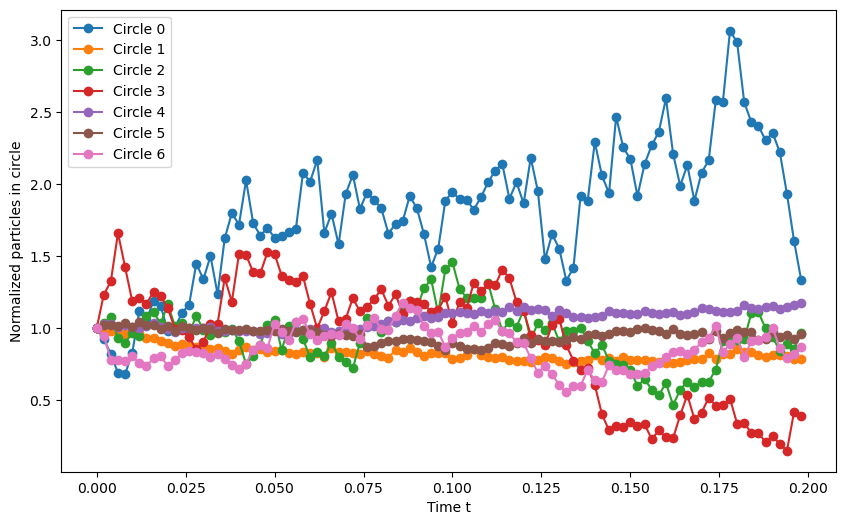

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

timeRange = np.arange(num_steps) * dt

# Trajectory
axes.plot(timeRange, particlesPerCircleNormalized[:, 0], 'o-', label='Circle 0')
axes.plot(timeRange, particlesPerCircleNormalized[:, 1], 'o-', label='Circle 1')
axes.plot(timeRange, particlesPerCircleNormalized[:, 2], 'o-', label='Circle 2')
axes.plot(timeRange, particlesPerCircleNormalized[:, 3], 'o-', label='Circle 3')
axes.plot(timeRange, particlesPerCircleNormalized[:, 4], 'o-', label='Circle 4')
axes.plot(timeRange, particlesPerCircleNormalized[:, 5], 'o-', label='Circle 5')
axes.plot(timeRange, particlesPerCircleNormalized[:, 6], 'o-', label='Circle 6')
axes.legend()
axes.set_xlabel('Time t')
axes.set_ylabel('Normalized particles in circle')
plt.show()